In [1]:
import pandas as pd

In [2]:
import sodapy
from sodapy import Socrata
import structlog
from urllib.parse import urlparse,urljoin

In [3]:
import time
import requests
from pprint import pformat

In [4]:
from portal import Portal
from comprehensive_set import compute_Comprehensive_Set
from category_alignment import compute_Alignment
from HVD_category import compute_HVD

In [5]:
from datasets_from_portal import getPortalProcessor, get_Portal_Datasets, extract_Categories_Usage, portals_ETL, portals_sample

In [6]:
from report import Plotpar, plot_views_kist_log, show_categories, portals_Unspecified 

In [7]:
from HVD_category import HVD_city_first_categories

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
portals=portals_sample()

In [10]:
columns=['URL','City','a','Engine','#datasets', 'Population']
df = pd.DataFrame(portals,columns=columns)
df.drop('a', axis=1, inplace=True) 
print (df)

                              URL           City   Engine #datasets Population
0    https://data.austintexas.gov         Austin  Socrata      4419     875463
1   https://data.cityofnewyork.us       New York  Socrata      3259    8272963
2      https://data.buffalony.gov        Buffalo  Socrata      2365     260041
3  https://data.cityofchicago.org        Chicago  Socrata      1790    2726772
4         https://data.lacity.org    Los Angeles  Socrata      1703    3883916
5  https://www.dallasopendata.com         Dallas  Socrata      1173    1259239
6          https://data.sfgov.org  San Francisco  Socrata      1133     839841
7        https://data.seattle.gov        Seattle  Socrata      1094     654224
8       https://data.honolulu.gov       Honolulu  Socrata       373     349275


In [11]:
import datetime as dt
from datetime import datetime

In [12]:
#dt=datetime.now().isoformat(timespec='minutes')
#output_dir = "output-"+dt+"/"
#for char in output_dir:
#    if char in ":":
#        output_dir=output_dir.replace(char,'')

In [13]:
output_dir = "output-2025-03-24T1141"+"/"

In [14]:
get=False       ##### Set to True to download all datasets from portals - save in AllPortalsDatasetsFile.json - into output_dir
usage=False     ##### Set to True to extract usage x portals categories 

## Gathering Usage Metadata ## 

### Download Metadata from Portals ###

In [15]:
portals_ETL(portals,output_dir,get,usage)  

### Extract Usage per Category ###

In [16]:
input_filename="AllPortalsDatasetsFile.json"
allPortalsDatasetsFile = output_dir + input_filename

In [17]:
portals_ETL(portals,output_dir,get=False,usage=False)

## Levels of interest in OGD portals ## 

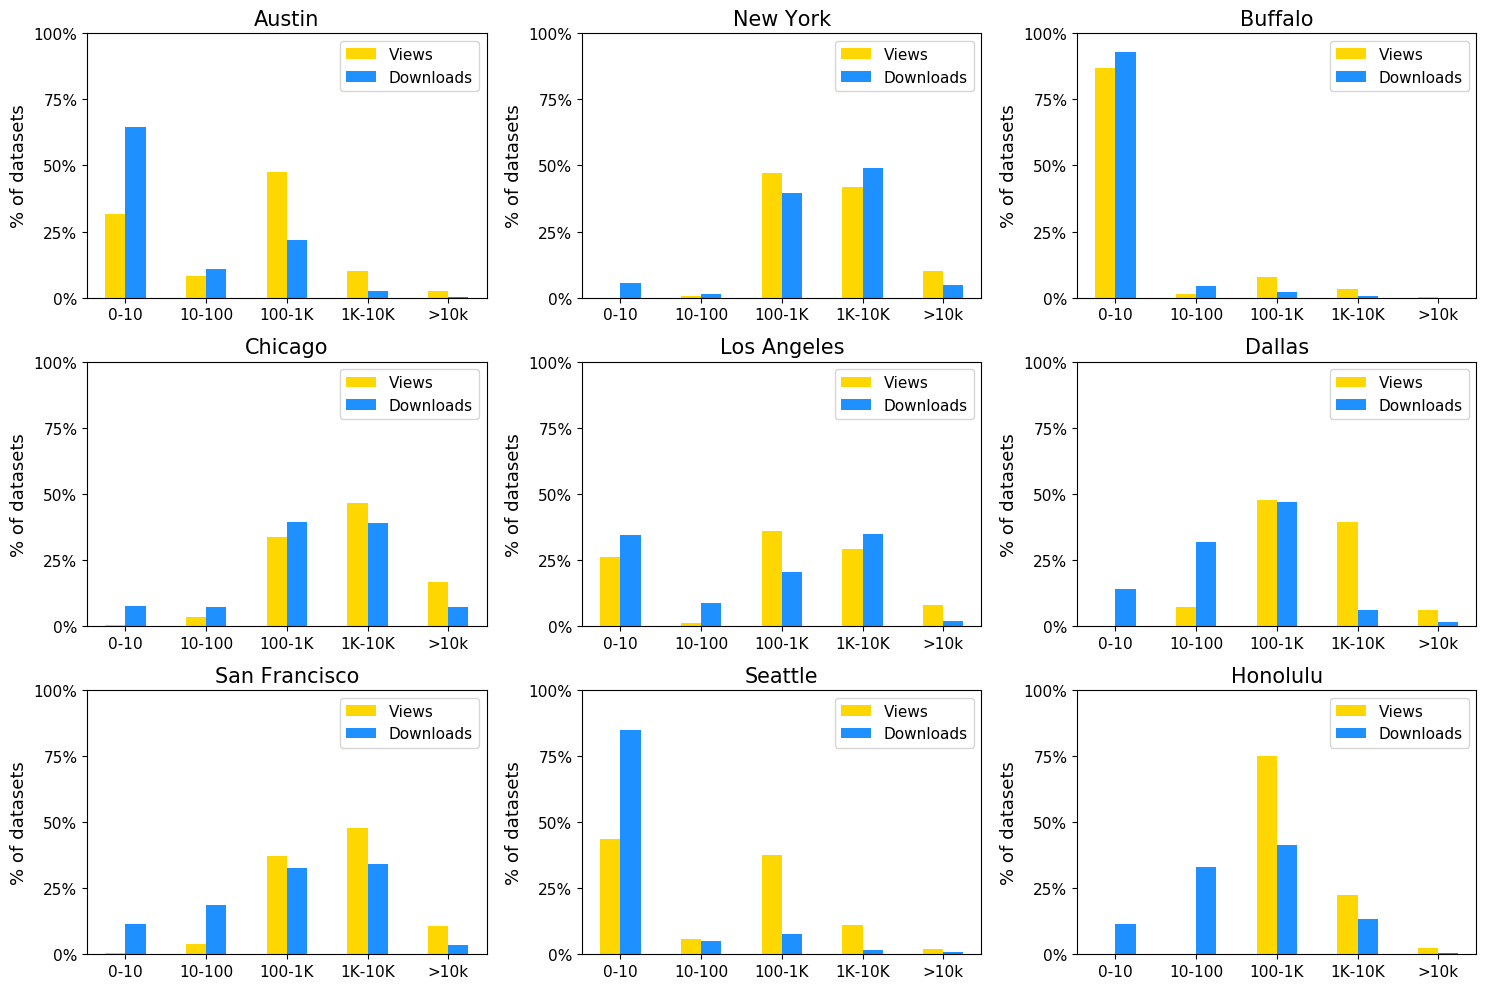

In [18]:
####portals = portals_sample()
#import matplotlib.pyplot as plt
plotpar = Plotpar(nrows=3, ncols=3, sharex=False, sharey=False, figsize=[15, 10], constrained_layout=True)
plot_views_kist_log(portals, allPortalsDatasetsFile, plotpar, typep='all', ylog=False, query=False, geospdt=False,
                    color='black')

<figure>
<figcaption align = "center" > <b>The overall distributions of Views and Downloads for the 9 US cities. Frequency numbers are grouped into five classes: 0–10, 10–100, 100–1000, 1000–10,000 and >10,000 </b></figcaption>
</figure>

<br>
<br>

## Extracting Thematic Information ##

In [19]:
portals = [["https://data.cityofnewyork.us", 'New York', ' ', 'Socrata', '3253', '8272963']]
plotpar = Plotpar(nrows=1, ncols=1, sharex=False, sharey=False, figsize=[8, 4], constrained_layout=True)

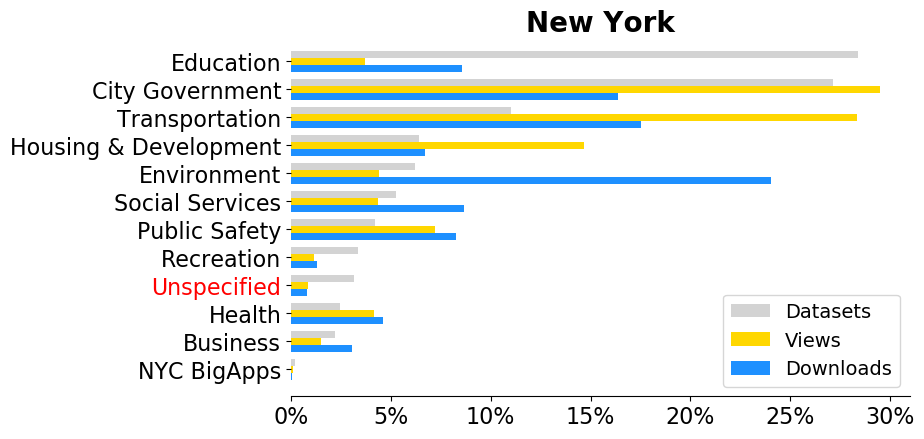

In [20]:
# Metrics datasets count:
show_categories(portals, allPortalsDatasetsFile, plotpar, 'lower right', True, False, False, False,True, False, False, False, False)

<figure>
<figcaption align = "center" > <b>NY portal categories, ordered by number of datasets per category </b></figcaption>
</figure>

<br>

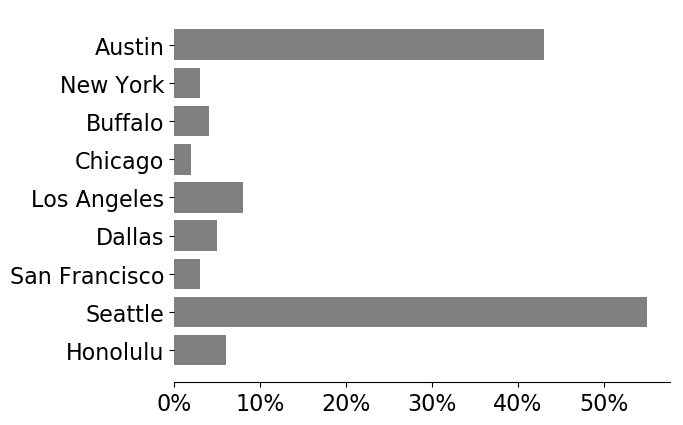

In [21]:
portals_Unspecified(output_dir)

<figure>
<figcaption align = "center" > <b>Percentage of not categorized datasets in the portals sample </b></figcaption>
</figure>

<br>
<br>

## Assessing Thematic Impact ##

Various metrics can be derived using simple statistical methods. In the following, we demonstrate this approach using the case of the New York portal. For the sake of clarity, the statistics of the dummy ’Unspecified’ category are not reported.

### Number of downloads ###

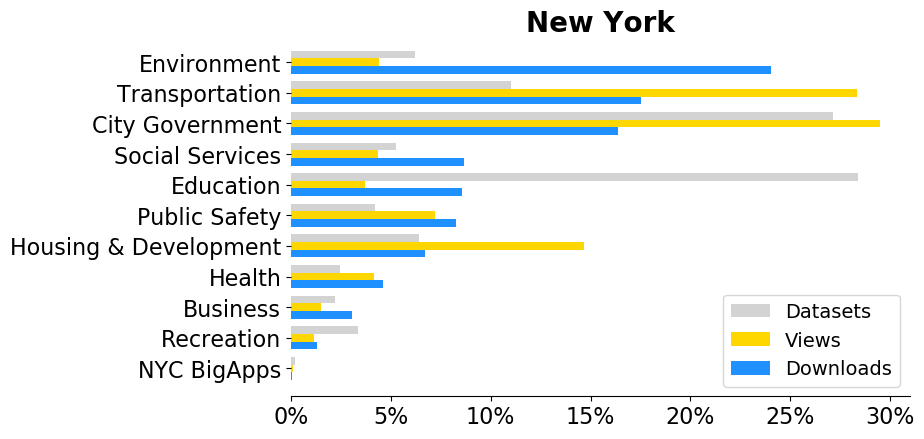

In [22]:
# Metrics number downloads:
show_categories(portals, allPortalsDatasetsFile, plotpar, 'lower right',False, False, False, False,False, True, False, False, False)

<figure>
<figcaption align = "center" > <b>NY portal categories, ordered by number of downloads </b></figcaption>
</figure>

<br>

### Mean and Median ###

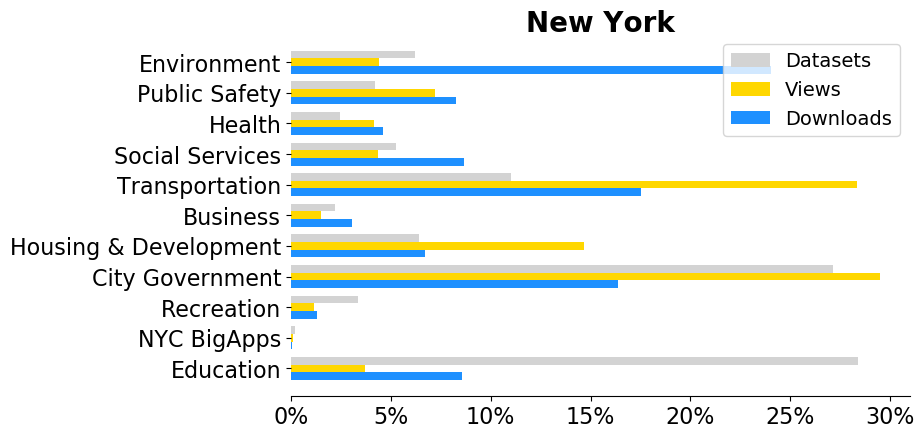

In [23]:
# Metrics mean downlaod:
show_categories(portals, allPortalsDatasetsFile, plotpar, 'upper right',False, False, False, False,False, False, True, False, False)

<figure>
<figcaption align = "center" > <b>NY portal categories, ordered by average downloads per datasets (Mean) </b></figcaption>
</figure>

<br>

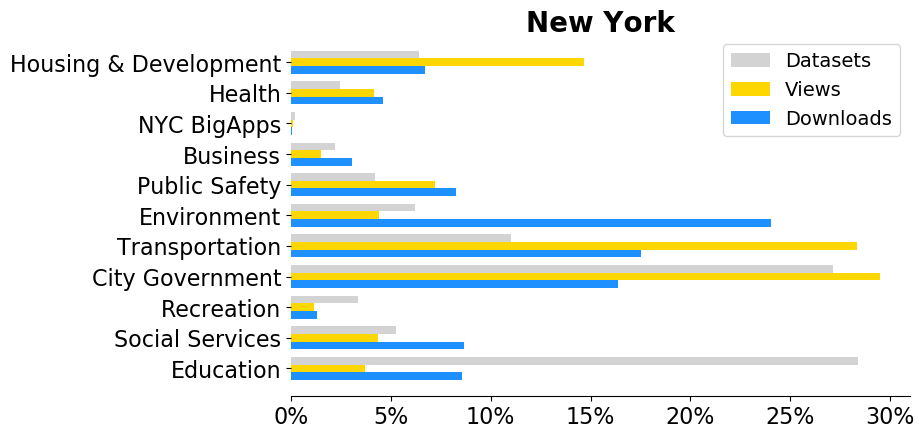

In [24]:
# Metrics median downlaod:
show_categories(portals, allPortalsDatasetsFile, plotpar, 'upper right',False, False, False, False,False, False, False, True, False)

<figure>
<figcaption align = "center" > <b>NY portal categories, ordered by the Median downloads </b></figcaption>
</figure>

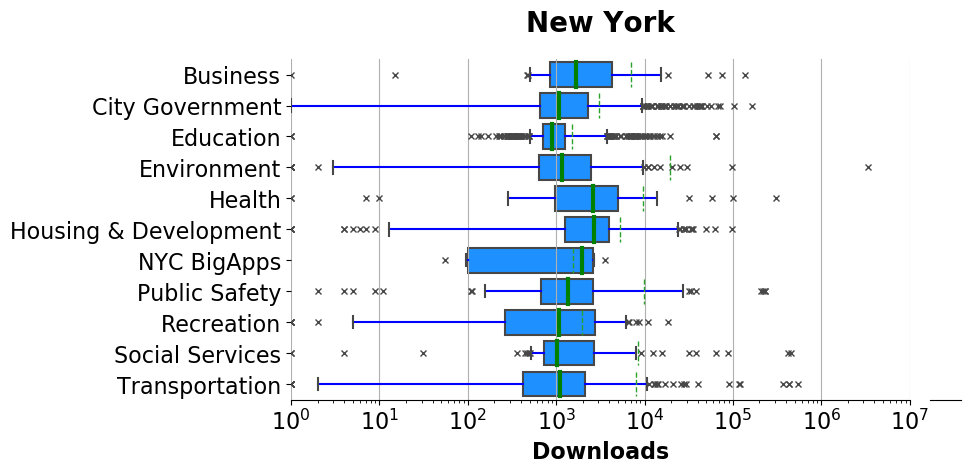

In [25]:
# BoxPLOT 95% (log=True)
show_categories(portals, allPortalsDatasetsFile, plotpar,'',False,True,True,True,False,False,False,False,False)   ### OK Write BoxPLOT 95% (log=True)

<figure>
<figcaption align = "center" > <b>NY portal categories, boxplot with download statistics. The median is represented by the center line, while the box’s limits indicate the 25th and 75th percentiles. Whiskers extend to the 5th and 95th percentiles, and outliers are denoted by crosses. </b></figcaption>
</figure>

<br>

### High-Value Data index ###

A metric that retains the robustness of the median while avoiding excessive penalization of categories with numerous widely downloaded datasets, also accounting for the absolute values of the published datasets. 


\begin{equation}
{HVDi} = median * \%datasets + \textit{95percentile} * (\%datasets * (1-0.95))
\end{equation}


where \%datasets is the percentage of datasets belonging to a category out of the total number of datasets published by a portal, and median and 95percentile are, respectively, the median and 95th percentile values of downloads for that category.

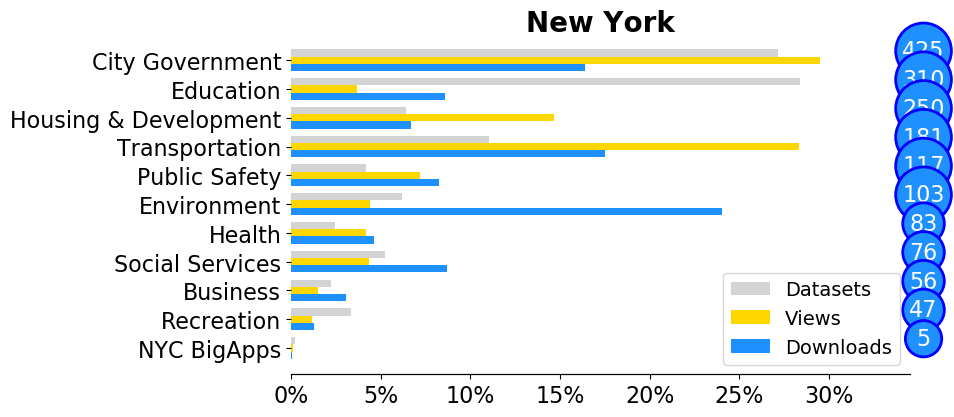

In [26]:
show_categories(portals, allPortalsDatasetsFile, plotpar, 'lower right',False,True, True, True, False, False, False, False, True)     ### stampa HVD, Index (blubles)

<figure>
<figcaption align = "center" > <b>NY portal categories, ordered by the High-Value Data index, whose value is listed in the right-side bubbles </b></figcaption>
</figure>

<br>

In [27]:
portalsFile = output_dir+"portals_category_usage.json"

In [28]:
HVD_city_first_categories(portalsFile,output_dir)

,I,II,III,IV,V,VI,VII
Austin,Utilities and City Services,Health and Community Services,City Infrastructure,Locations and Maps,Public Safety,Building and Development,Budget and Finance
New York,City Government,Education,Housing & Development,Transportation,Public Safety,Environment,Health
Buffalo,Economic & Neighborhood Development,Quality of Life,Government,Public Safety,Infrastructure,Economic Development,Education
Chicago,FOIA,Transportation,Public Safety,Environment & Sustainable Development,Education,Health & Human Services,Administration & Finance
Los Angeles,City Infrastructure & Service Requests,A Prosperous City,Administration & Finance,Community & Economic Development,Transportation,Housing and Real Estate,Public Safety
Dallas,Public Safety,Services,Archive,Economy,Other,GIS,None
San Francisco,Health and Social Services,City Management and Ethics,Transportation,Geographic Locations and Boundaries,,Housing and Buildings,Public Safety
Seattle,Community and Culture,City Administration,Built Environment,Transportation,Public Safety,Community,Land Base
Honolulu,Finance,Transportation,business,Business,Location,Public Safety,Recreation


<figure>
<figcaption align = "center" > <b>The first 7 categories according to HDVi ranking (based on usage data) </b></figcaption>
</figure>

## Discovering categorization differences and similarities among High-Value Datasets across various regions/countries ##

Standardize the categorization across various portals within a country (or a region). The standardization process occurs in two phases. 
- The first phase aims to identify the most prevalent categories across a set of portals. 
- The second phase is aimed at aligning the categories of individual portals with those that are most prevalent overall.

### Identifying Most Prevalent Categories Across Multiple Portals ###

Following [REF] construct the Comprehensive Subset of Categorie collection “containing the most frequent categories” (Pinto et al., 2022) starting from a set of 100 US portals (FILE)

In [45]:
CSC=False # True to compute the Comprehensive_Set
if CSC:
    csc=compute_Comprehensive_Set(output_dir)  ### It takes several minutes to process the categories of the 100 portals in 'portals.json'
else:    
    csc = pd.read_json(output_dir+"most_coverage_categories.json")

In [47]:
df = pd.DataFrame(df,range(0,math.ceil(len(csc)/5)))
print(df.to_string(index=False, header=False))

  Public Safety   Transportation         City Services  Recreation     Boundaries
       Planning      Environment  Economic Development      Health      Education
          Parks         Business               Housing   Community     Government
 Infrastructure          Culture               Finance     Economy       Property
         Zoning     Land Records          Demographics   Utilities  Neighborhoods
   Public Works  Social Services      Service Requests      Budget     Facilities
      Elections          Permits                  None        None           None


<figure>
<figcaption align = "center" > <b>Comprehensive Subset of Categories extracted from the 100 portals of American cities (left to right, top to bottom) </b></figcaption>
</figure>

<br>
<br>

In [ ]:
CSC=False           # True to compute the Comprehensive_Set
align=False         # True to compute the Alignment
HVD=True            # True to compute HVD and print results into charts and tables

### Aligning Portal Categories ###